In [1]:
import powerlaw
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from collections import Counter
# import numpy as np
# import seaborn as sns
import xgi
# from matplotlib import cm
# from draw import *
notebook_dir = os.getcwd()  # This gets the current working directory in Jupyter
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from sod import *
from sod.simpliciality import edit_simpliciality
# from sod.simpliciality import edge_rewiring
from edge_rewiring import edge_rewiring_alg
from edge_rewiring import edge_rewiring_exper
from edge_rewiring import power_law

[0, 9, 3, 1]
[0, 9, 1]
[0, 3]
[0, 2, 4, 5]
[0, 2]
[0, 4]
[0, 5]
sum: 4
Edit simpliciality for: 0.3181818181818182


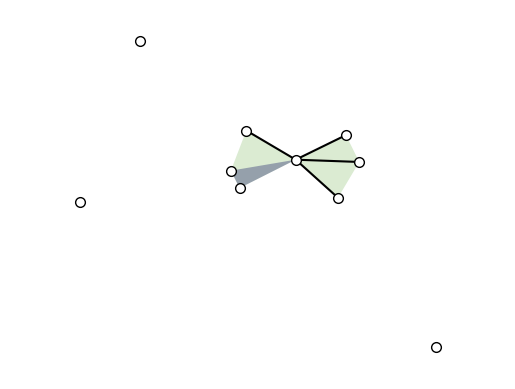

In [2]:
from edge_rewiring import model_generation
import matplotlib.pyplot as plt
import math

# Generate hypergraph
# H = xgi.load_xgi_data(edge_rewiring_exper.datasets[0], max_order=11)
H = model_generation.model_generation_es(es=.3, approx_num_C=16, num_max_hyperedge=2,num_node=10, min_size=2, max_size=None)
for edge in H.edges.members():
    print(list(edge))
sum = 0
for i in range(2, 3 + 1):
    sum += math.comb(i, 2)
print(f"sum: {sum}")


xgi.draw(H)
curr_es = edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality for: {curr_es}")


In [3]:
H = model_generation.model_generation_sf(sf=0.3, approx_num_E=1000, num_node=1000, min_size=2, max_size=None)
for edge in H.edges.members():
    print(list(edge))

[880, 887]
[880, 667]
[880, 978]
[880, 100]
[667, 887]
[978, 887]
[100, 887]
[978, 667]
[667, 100]
[978, 100]
[880, 667, 887]
[880, 978, 887]
[880, 100, 887]
[880, 978, 667]
[880, 667, 100]
[880, 978, 100]
[978, 667, 887]
[667, 100, 887]
[978, 100, 887]
[978, 667, 100]
[880, 978, 667, 887]
[880, 667, 100, 887]
[880, 978, 100, 887]
[880, 978, 667, 100]
[978, 667, 100, 887]
[880, 978, 100, 887, 667]
[584, 881]
[960, 691]
[960, 698]
[960, 907]
[960, 635]
[698, 691]
[691, 907]
[635, 691]
[698, 907]
[698, 635]
[635, 907]
[960, 698, 691]
[960, 691, 907]
[960, 635, 691]
[960, 698, 907]
[960, 698, 635]
[960, 635, 907]
[698, 691, 907]
[635, 698, 691]
[635, 691, 907]
[635, 698, 907]
[960, 698, 691, 907]
[960, 635, 698, 691]
[960, 635, 691, 907]
[960, 635, 698, 907]
[635, 698, 691, 907]
[960, 691, 635, 698, 907]
[320, 643]
[643, 28]
[643, 348]
[867, 643]
[643, 118]
[914, 643]
[320, 28]
[320, 114]
[320, 867]
[320, 118]
[28, 348]
[114, 28]
[867, 28]
[28, 118]
[914, 28]
[867, 348]
[914, 348]
[114, 9

Hypergraph named email-Enron with 148 nodes and 10885 hyperedges
[3, 5, 6, 6, 6, 10, 12, 12, 13, 14, 14, 15, 15, 16, 18, 19, 19, 20, 20, 20, 21, 22, 22, 23, 24, 25, 25, 29, 30, 32, 32, 33, 34, 34, 35, 38, 38, 40, 43, 46, 47, 48, 48, 49, 49, 50, 51, 56, 57, 58, 58, 62, 67, 67, 69, 69, 70, 70, 70, 72, 75, 78, 83, 83, 87, 89, 93, 94, 97, 104, 108, 111, 111, 117, 117, 119, 122, 123, 126, 128, 130, 131, 134, 137, 138, 140, 142, 150, 153, 154, 157, 157, 165, 167, 171, 172, 174, 175, 192, 197, 202, 208, 209, 209, 226, 237, 238, 240, 257, 260, 272, 281, 301, 308, 309, 317, 322, 328, 338, 354, 357, 362, 368, 377, 389, 394, 399, 415, 419, 428, 466, 494, 501, 502, 510, 627, 754, 880, 906, 967, 1097, 1282, 1327]
Calculating best minimal value for power law fit
Power-law alpha: 3.0909
xmin: 301.0
Sigma: 0.3755
Loglikelihood ratio R: 1.1319
p-value: 0.4750


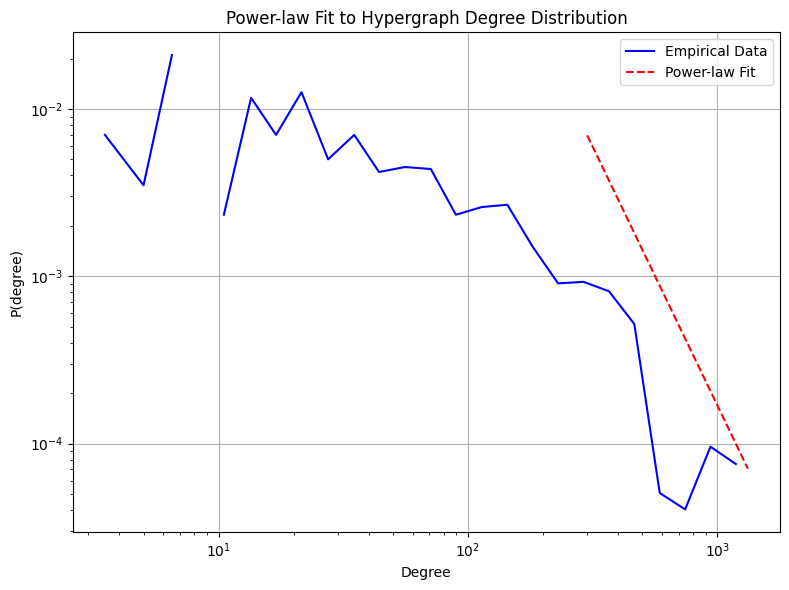

In [4]:
from edge_rewiring import edge_rewiring_alg

H = xgi.load_xgi_data(edge_rewiring_exper.datasets[3])
# es = edit_simpliciality(H, min_size=2)
# print(f"Edit simpliciality: {es}")

print(H)
degree_dict = H.degree()
#print(degree_dict)
degree_list = list(degree_dict.values())
#print(degree_list)
sorted_degrees = sorted(degree_dict.values())
filtered_degrees = [d for d in sorted_degrees if d > 0]
print(filtered_degrees)

fit = powerlaw.Fit(filtered_degrees)
print(f"Power-law alpha: {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")
print(f"Sigma: {fit.power_law.sigma:.4f}")

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(filtered_degrees, color='b', label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
from edge_rewiring import power_law
import xgi
from edge_rewiring import edge_rewiring_exper
from edge_rewiring import power_law

H = xgi.load_xgi_data(edge_rewiring_exper.datasets[4])
print(H)
# H.cleanup(singletons=True)

result = power_law.has_powerlaw(H, p_value=0.10)
print(result)

print("Follows power-law:" if result else "Does not follow power-law.")


Hypergraph named email-Eu with 1005 nodes and 235263 hyperedges
Calculating best minimal value for power law fit
  R = 8.0859, p = 0.0439
False
Does not follow power-law.


In [ ]:
H = model_generation.model_generation_es(es=.5, approx_num_C=1000, num_max_hyperedge=70, num_node=50, min_size=2, max_size=None)
print(H)
# H.cleanup(singletons=True)

result = power_law.has_powerlaw(H, p_value=0.10)
print(result)

print("Follows power-law:" if result else "Does not follow power-law.")


Unnamed Hypergraph with 50 nodes and 662 hyperedges
Calculating best minimal value for power law fit
  R = -0.0392, p = 0.7609
False
Does not follow power-law.
